Ridge Regression Results :
-------------------------------------------------------------------------------------
Degree   Alpha    MSE_Train    MSE_Test     R²_Train     R²_Test     
-------------------------------------------------------------------------------------
1        0.0002   2009.3935    1407.6168    0.0003       -0.0077     
1        0.002    2009.3935    1407.6168    0.0003       -0.0077     
1        0.02     2009.3935    1407.6170    0.0003       -0.0077     
1        0.1      2009.3935    1407.6178    0.0003       -0.0077     
1        0.5      2009.3935    1407.6220    0.0003       -0.0077     
1        0.95     2009.3935    1407.6267    0.0003       -0.0077     
1        2.5      2009.3935    1407.6429    0.0003       -0.0077     
1        5        2009.3936    1407.6689    0.0003       -0.0077     
2        0.0002   92.9806      110.9039     0.9537       0.9206      
2        0.002    92.9806      110.9038     0.9537       0.9206      
2        0.02     92.9806      

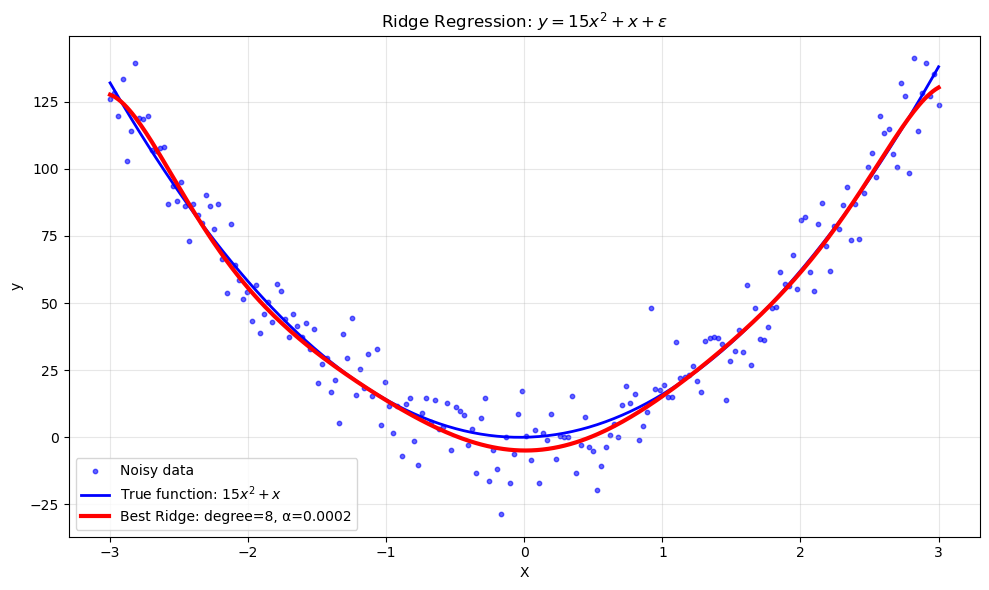

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Set random seed for reproducibility
np.random.seed(40)

# Create sample dataset: y = 15x^2 + x + random noise
def generate_data(n_samples=200):
    X = np.linspace(-3, 3, n_samples)
    y_true = 15*X**2 + X
    noise = np.random.normal(0, 10, n_samples)
    y = y_true + noise
    return X.reshape(-1, 1), y, y_true

# Generate dataset
X, y, y_true = generate_data()

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=40)

# Function to evaluate Ridge regression with various parameters
def evaluate_ridge_models(X_train, X_test, y_train, y_test, degrees, alphas):
    results = []
    for degree in degrees:
        for alpha in alphas:
            # Create pipeline with Ridge regression
            model = make_pipeline(
                PolynomialFeatures(degree=degree), 
                linear_model.Ridge(alpha=alpha, random_state=0)
                )

            # Train Ridge regression model
            model.fit(X_train, y_train)
            
            # Generate predictions
            y_train_pred = model.predict(X_train)
            y_test_pred = model.predict(X_test)
            
            # Calculate performance metrics
            train_mse = mean_squared_error(y_train, y_train_pred)
            test_mse = mean_squared_error(y_test, y_test_pred)
            train_r2 = r2_score(y_train, y_train_pred)
            test_r2 = r2_score(y_test, y_test_pred)
            
            results.append({
                'degree': degree,
                'alpha': alpha,
                'train_mse': train_mse,
                'test_mse': test_mse,
                'train_r2': train_r2,
                'test_r2': test_r2,
                'model': model
            })
    return results

# Define parameter ranges to test
degrees = [1, 2, 3, 5, 8, 9, 10]
alphas = [0.0002, 0.002, 0.02, 0.1, 0.5, 0.95, 2.5, 5]

# Evaluate all parameter combinations
results = evaluate_ridge_models(X_train, X_test, y_train, y_test, degrees, alphas)

# Identify best model based on test MSE
best_model = min(results, key=lambda x: x['test_mse'])

# Display results in a table 
print("Ridge Regression Results :")
print("-" * 85)
print(f"{'Degree':<8} {'Alpha':<8} {'MSE_Train':<12} {'MSE_Test':<12} {'R²_Train':<12} {'R²_Test':<12}")
print("-" * 85)

for result in results:
    if result == best_model:
        print(f"\033[1m{result['degree']:<8} {result['alpha']:<8} {result['train_mse']:<12.4f} "
              f"{result['test_mse']:<12.4f} {result['train_r2']:<12.4f} {result['test_r2']:<12.4f}\033[0m")
    else:
        print(f"{result['degree']:<8} {result['alpha']:<8} {result['train_mse']:<12.4f} "
              f"{result['test_mse']:<12.4f} {result['train_r2']:<12.4f} {result['test_r2']:<12.4f}")

def plot_results(X, y, y_true, best_model):
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 6))   
    
    # Plot original data points
    ax.scatter(X, y, alpha=0.6, label='Noisy data', color='blue', s=10)  
    
    # Plot true function 
    ax.plot(X, y_true, 'b-', linewidth=2, label='True function: $15x^2 + x$')  
    
    # Plot best model's predictions
    X_plot = np.linspace(-3, 3, 300).reshape(-1, 1)
    y_plot_pred = best_model['model'].predict(X_plot)
    
    ax.plot(X_plot, y_plot_pred, 'r-', linewidth=3, 
             label=f'Best Ridge: degree={best_model["degree"]}, α={best_model["alpha"]}')
    
    ax.set_xlabel('X')
    ax.set_ylabel('y')
    ax.set_title('Ridge Regression: $y = 15x^2 + x + \epsilon$')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    fig.tight_layout()
    plt.show()

plot_results(X, y, y_true, best_model)